# HealthConnect Clinic: No-Show Prediction
### Week 5 Data Science Track: Data Preparation, Feature Engineering & Baseline Model Development
### AnalystLab Africa Experience Lab

**Prepared by:** Data Science Intern
**Project:** HealthConnect Clinic Experience Lab
**Track:** Data Science

Week 4 asked whether the HealthConnect appointment data could support a no-show prediction model, and concluded that it can: the dataset is structurally clean, the target is close to balanced once cancellations are excluded, and `previous_no_shows` and `booking_lead_days` stood out as the strongest early signals.

Week 5 moves from that assessment into actual practical work: cleaning and preparing the data, engineering features, choosing a train/test strategy, and building and evaluating a first baseline model. Nothing here is meant to be the final solution — the goal is a reliable, well-documented starting point for Week 6.

## 1. Review of the Week 4 Foundation

**Problem addressed:** Whether HealthConnect's appointment data can support a model that predicts, ahead of time, which appointments are at risk of ending in a no-show, so the clinic can intervene before the slot is lost.

**Week 4 proposed approach:** Frame this as binary classification (no-show vs. attended), excluding cancellations from the target. Start with a simple baseline, then logistic regression for interpretability, then a tree-based model to check for feature interactions. Split by patient rather than by row to avoid leakage from repeat patients.

**Resources used:** `HealthConnect_Appointment_Data.csv` (5,000 appointment records) and the HealthConnect Data Dictionary, to confirm variable definitions and expected value ranges.

**Key assumptions/limitations carried over from Week 4:**
- The dataset is synthetic and anonymised but assumed representative enough to be useful for building and testing an approach.
- `previous_no_shows` / `previous_appointments` are assumed to count only appointments strictly before the current one.
- `waiting_time_minutes` was flagged as a possible timing/leakage risk, pending a decision on whether it is known before or after the appointment.
- There is no information on *why* a patient missed an appointment, which will limit how targeted any resulting intervention can be.

**Proposed focus for Week 5 (from the Week 4 summary):** Clean and impute the flagged columns, engineer the age- and history-based features identified in Week 4, build the baseline and a first logistic regression model, and get an initial read on performance against that baseline. This notebook carries that plan out.

## 2. Data Preparation

We start from the same raw file used in Week 4. The original CSV is never modified — all cleaning happens on an in-memory copy, and any derived files are saved separately under `/processed`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, classification_report)

pd.set_option('display.max_columns', None)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head(3)

Rows: 5000, Columns: 18


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show


### 2.1 Recap of data-quality findings (confirmed in Week 4)

- No duplicate `appointment_id` values and no duplicate rows.
- No logical inconsistencies: `previous_no_shows` never exceeds `previous_appointments`, and `booking_lead_days` is never negative.
- Missing values are limited to three columns: `reminder_channel`, `distance_to_clinic_km`, `waiting_time_minutes`.

These checks are re-run quickly below to confirm the file hasn't changed, then we move straight into handling each missing-value column on its own terms.

In [2]:
print("Duplicate appointment IDs:", df['appointment_id'].duplicated().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Rows where previous_no_shows > previous_appointments:", (df['previous_no_shows'] > df['previous_appointments']).sum())
print("Rows with negative booking_lead_days:", (df['booking_lead_days'] < 0).sum())
print()
missing = df.isnull().sum()
missing = missing[missing > 0]
pd.DataFrame({'missing_count': missing, 'missing_pct': (missing/len(df)*100).round(1)})

Duplicate appointment IDs: 0
Duplicate rows: 0
Rows where previous_no_shows > previous_appointments: 0
Rows with negative booking_lead_days: 0



,missing_count,missing_pct
reminder_channel,1366,27.3
distance_to_clinic_km,90,1.8
waiting_time_minutes,60,1.2


### 2.2 Handling `reminder_channel`

Week 4 confirmed that every row missing `reminder_channel` is a row where `reminder_sent` is "No" — there's no channel to record because nothing was sent. This is filled with an explicit `"None"` category rather than imputed statistically, since it isn't a gap in the data, it's a genuine value that was left blank by the source system.

In [3]:
assert df.loc[df['reminder_channel'].isnull(), 'reminder_sent'].eq('No').all(), "Unexpected: some missing reminder_channel rows have a reminder sent"
df['reminder_channel'] = df['reminder_channel'].fillna('None')
print("Remaining missing reminder_channel:", df['reminder_channel'].isnull().sum())

Remaining missing reminder_channel: 0


### 2.3 Handling `distance_to_clinic_km`

90 rows (1.8%) are missing this value, with no explanatory pattern tied to another column (checked against outcome and appointment type — the missing rows aren't concentrated in any one group). This looks like a genuine, unexplained gap, most likely a data-entry omission for a synthetic dataset. Given the small proportion, we impute with the **median** distance (robust to the right-skew typical of distance data) and add a `distance_missing_flag` so the model can still learn if "distance was unknown" itself carries any signal, rather than silently hiding that information.

In [4]:
print("Outcome split among rows missing distance:")
print(df.loc[df['distance_to_clinic_km'].isnull(), 'appointment_outcome'].value_counts(normalize=True).round(3))

distance_median = df['distance_to_clinic_km'].median()
df['distance_missing_flag'] = df['distance_to_clinic_km'].isnull().astype(int)
df['distance_to_clinic_km'] = df['distance_to_clinic_km'].fillna(distance_median)
print(f"\nImputed distance_to_clinic_km with median = {distance_median} km")
print("Remaining missing distance_to_clinic_km:", df['distance_to_clinic_km'].isnull().sum())

Outcome split among rows missing distance:
appointment_outcome
No-Show      0.522
Attended     0.433
Cancelled    0.044
Name: proportion, dtype: float64

Imputed distance_to_clinic_km with median = 8.7 km
Remaining missing distance_to_clinic_km: 0


### 2.4 Handling `waiting_time_minutes` — a timing decision, not just a missing-value decision

Week 4 flagged `waiting_time_minutes` as a possible leakage risk because of *when* it can plausibly be known. Checking it directly:

In [5]:
print(pd.crosstab(df['appointment_outcome'], df['waiting_time_minutes'].isnull()))

waiting_time_minutes  False  True 
appointment_outcome               
Attended               2293     21
Cancelled               261      2
No-Show                2386     37


`waiting_time_minutes` is populated for the large majority of no-shows as well as attended appointments, so statistically it doesn't perfectly separate the classes. But that isn't the real question. The prediction this model needs to make happens **before the appointment**, at booking time or shortly before — and a patient's waiting time in the clinic is, by definition, only known once the appointment (or the attempt at it) has actually happened.

**Decision:** `waiting_time_minutes` is excluded from the feature set entirely, regardless of its raw correlation with the target. This is a timing/availability decision, not a data-quality one — including it would let the model "see the future" relative to the point at which HealthConnect would actually need a prediction. This confirms the concern raised in Week 4 rather than changing course.

In [6]:
FEATURE_EXCLUDE_LEAKAGE = ['waiting_time_minutes']
print("Excluded from modelling (timing/leakage):", FEATURE_EXCLUDE_LEAKAGE)

Excluded from modelling (timing/leakage): ['waiting_time_minutes']


### 2.5 Target variable and cancellations

As defined in Week 4: `is_no_show` = 1 if `appointment_outcome` is "No-Show", 0 if "Attended". Cancelled appointments (5.3% of rows) are excluded from the modelling set — a cancellation is a patient proactively telling the clinic they won't attend, which is a fundamentally different (and more manageable) situation than a silent no-show, so folding it into the same target would blur two different behaviours together.

In [7]:
df_model = df[df['appointment_outcome'] != 'Cancelled'].copy()
df_model['is_no_show'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)

print(f"Rows available for modelling: {len(df_model)} (of {len(df)} total)")
print(f"No-show rate in modelling set: {df_model['is_no_show'].mean():.1%}")

Rows available for modelling: 4737 (of 5000 total)
No-show rate in modelling set: 51.2%


### 2.6 Saving the processed dataset

Per the project resource rules, the cleaned data is saved to a new file rather than overwriting the original.

In [8]:
import os
os.makedirs('processed', exist_ok=True)
df_model.to_csv('processed/HealthConnect_Appointment_Data_cleaned.csv', index=False)
print("Saved: processed/HealthConnect_Appointment_Data_cleaned.csv")

Saved: processed/HealthConnect_Appointment_Data_cleaned.csv


## 3. Data Exploration & Visual Evidence

A small set of targeted visuals — enough to justify the feature-engineering and modelling choices that follow, not exhaustive EDA for its own sake.

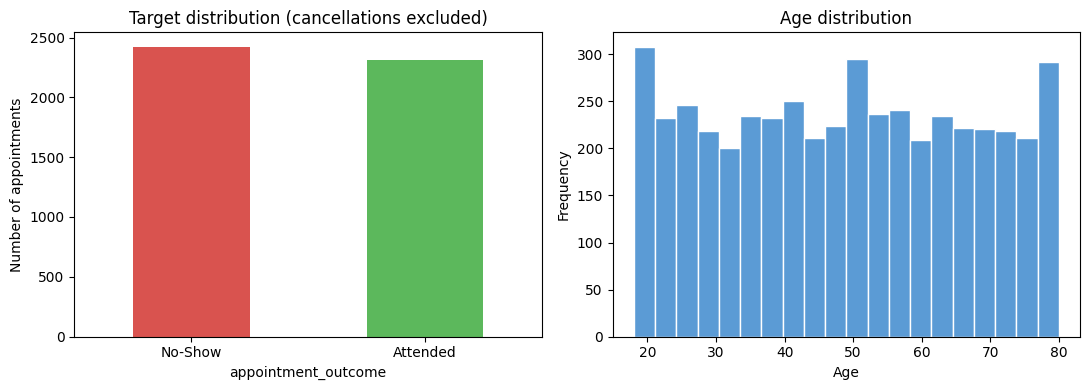

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df_model['appointment_outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['#d9534f', '#5cb85c'])
axes[0].set_title('Target distribution (cancellations excluded)')
axes[0].set_ylabel('Number of appointments')
axes[0].tick_params(axis='x', rotation=0)

df_model['age'].plot(kind='hist', bins=20, ax=axes[1], color='#5b9bd5', edgecolor='white')
axes[1].set_title('Age distribution')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.savefig('processed/fig1_target_age.png', dpi=100)
plt.show()

**What this shows:** the modelling target is close to balanced (about 51% no-show vs. 49% attended), confirmed again after cleaning — this means accuracy is a meaningful metric here and we don't need resampling techniques to correct severe imbalance. The age distribution is fairly broad with a mild concentration in the 25–54 range and no extreme outliers, so age is usable as-is without needing to cap or transform it.

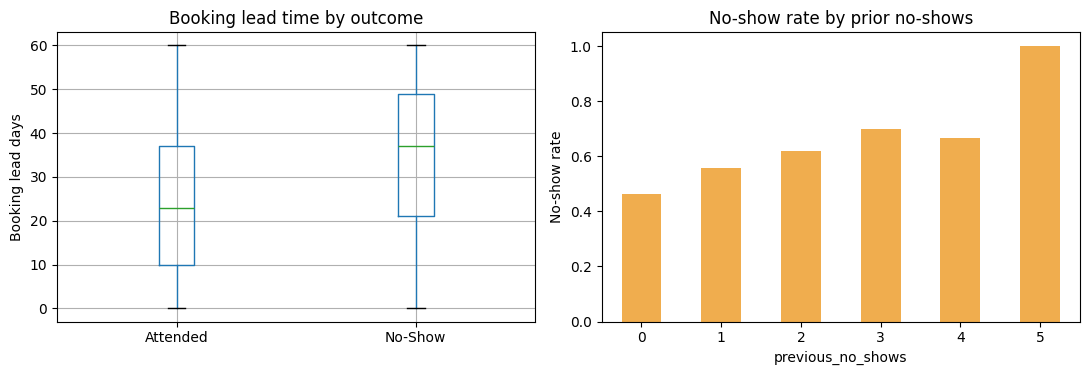

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df_model.boxplot(column='booking_lead_days', by='appointment_outcome', ax=axes[0])
axes[0].set_title('Booking lead time by outcome')
axes[0].set_xlabel('')
axes[0].set_ylabel('Booking lead days')
plt.suptitle('')

noshow_by_history = df_model.groupby('previous_no_shows')['is_no_show'].mean()
noshow_by_history.plot(kind='bar', ax=axes[1], color='#f0ad4e')
axes[1].set_title('No-show rate by prior no-shows')
axes[1].set_ylabel('No-show rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('processed/fig2_leadtime_history.png', dpi=100)
plt.show()

**What this shows:** patients who eventually no-show tend to have booked further in advance than those who attend — a longer gap between booking and the appointment date appears to give more room for a no-show to happen (competing plans, forgetting, etc.). This supports engineering explicit `short_lead_time` / `long_lead_time` flags rather than relying on the raw day count alone to carry a linear relationship. The second panel confirms the Week 4 finding: no-show rate climbs steadily from around 46% at zero prior no-shows to roughly 70% at three or more, the clearest single pattern in the data — this justifies engineering a *rate*-based history feature, not just the raw counts.

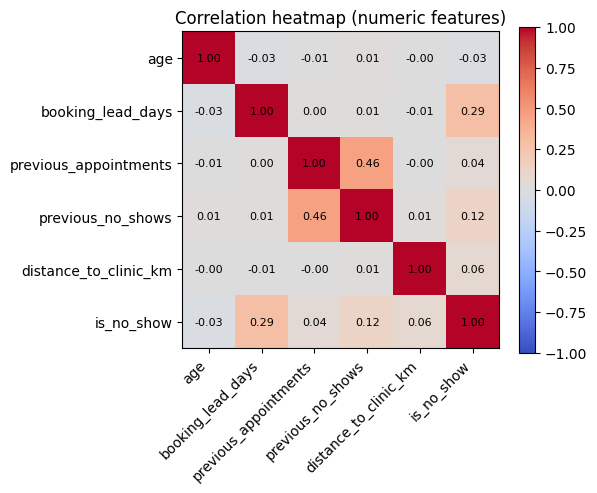

In [11]:
numeric_cols = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                'distance_to_clinic_km', 'is_no_show']
corr = df_model[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im)
ax.set_title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.savefig('processed/fig3_corr_heatmap.png', dpi=100)
plt.show()

**What this shows:** `previous_no_shows` and `booking_lead_days` have the strongest (still modest) individual correlations with `is_no_show`; `previous_appointments` and `distance_to_clinic_km` are weak on their own. No pair of numeric features is highly collinear with another, so there's no immediate need to drop a numeric feature for redundancy — engineered features are added on top of these rather than replacing them.

## 4. Feature Engineering

Each feature below is built to sharpen a signal that the raw columns only express weakly on their own, based directly on the patterns observed above.

In [12]:
df_model['no_show_rate_history'] = np.where(
    df_model['previous_appointments'] > 0,
    df_model['previous_no_shows'] / df_model['previous_appointments'],
    0
)
df_model['is_first_appointment'] = (df_model['previous_appointments'] == 0).astype(int)
df_model['short_lead_time'] = (df_model['booking_lead_days'] <= 3).astype(int)
df_model['long_lead_time'] = (df_model['booking_lead_days'] >= 30).astype(int)
df_model['is_weekend_appt'] = df_model['appointment_day'].isin(['Saturday', 'Sunday']).astype(int)

engineered = ['no_show_rate_history', 'is_first_appointment', 'short_lead_time', 'long_lead_time', 'is_weekend_appt']
df_model[engineered].describe()

,no_show_rate_history,is_first_appointment,short_lead_time,long_lead_time,is_weekend_appt
count,4737.000000,4737.000000,4737.000000,4737.000000,4737.000000
mean,0.169127,0.048132,0.062698,0.500528,0.292801
std,0.244076,0.214067,0.242444,0.500053,0.455096
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.333333,0.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


**`no_show_rate_history`** — prior no-shows expressed as a *rate* (`previous_no_shows / previous_appointments`) rather than a raw count. A patient with 1 no-show out of 1 appointment and one with 1 no-show out of 10 have very different reliability, but the raw count treats them the same; the rate separates them. Expected to be one of the stronger features, alongside the raw counts.

**`is_first_appointment`** — flags patients with no appointment history at HealthConnect at all (`previous_appointments == 0`), for whom `no_show_rate_history` is set to 0 by construction — a first-time patient hasn't "proven" reliable, they simply have no track record yet, and this flag lets the model tell the two situations apart instead of treating an absence of history as identical to a clean history.

**`short_lead_time`** / **`long_lead_time`** — binary flags for bookings made 3 days or less, and 30 days or more, before the appointment, based on the lead-time pattern observed above. Expected value: lets the model capture a threshold effect (long lead times relating to more no-shows) more directly than the raw day count would on its own.

**`is_weekend_appt`** — whether the appointment falls on a Saturday or Sunday. Included to test whether weekend scheduling behaves differently from weekday scheduling; expected to be a minor feature given how few appointments in the dataset fall on a weekend.

`distance_missing_flag` (created during data preparation) is also carried forward into modelling as a feature in its own right, in case "distance was unknown" is itself informative rather than just a gap to be filled in.

## 5. Train/Test Strategy

Week 4 flagged that patients appear more than once in the dataset (fewer unique `patient_id` values than rows). A plain random row-level split risks letting the same patient's history appear in both the training and test sets, which would let the model partly memorise individual patients rather than generalise to new ones.

**Approach:** a **group-based 80/20 split using `GroupShuffleSplit`, grouped by `patient_id`**, so that every appointment belonging to a given patient ends up entirely in the training set or entirely in the test set — never split across both. This is the appropriate strategy specifically *because* of the repeated-patient structure identified in Week 4; a standard `train_test_split` would not respect that structure.

In [13]:
numeric_features = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                    'distance_to_clinic_km', 'distance_missing_flag',
                    'no_show_rate_history', 'is_first_appointment',
                    'short_lead_time', 'long_lead_time', 'is_weekend_appt']
categorical_features = ['gender', 'appointment_type', 'appointment_day', 'appointment_time',
                         'reminder_sent', 'reminder_channel']

X = df_model[numeric_features + categorical_features]
y = df_model['is_no_show']
groups = df_model['patient_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

overlap = set(df_model.iloc[train_idx]['patient_id']) & set(df_model.iloc[test_idx]['patient_id'])

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Train no-show rate: {y_train.mean():.1%}  |  Test no-show rate: {y_test.mean():.1%}")
print(f"Patients appearing in both train and test: {len(overlap)}")

Train size: 3771  |  Test size: 966
Train no-show rate: 51.4%  |  Test no-show rate: 50.0%
Patients appearing in both train and test: 0


The split confirms zero patient overlap, and the no-show rate stays close to the overall ~51% in both sets, so the split hasn't accidentally skewed the class balance.

## 6. Baseline Model(s)

Two non-learned baselines are established first, so that any real model has a clear bar to clear:

1. **Majority-class baseline** — always predicts the more common class.
2. **Simple rule baseline** — flags an appointment as a likely no-show if `previous_no_shows >= 2`, directly reflecting the strongest pattern found in Week 4/above.

Then a **logistic regression** model is trained as the first learned baseline, chosen for interpretability: at this stage, understanding *which* factors matter to HealthConnect is as valuable as raw predictive power, and logistic regression's coefficients are directly readable. A **decision tree** is trained alongside it purely for comparison, per the Week 4 plan to check whether a tree-based model picks up feature interactions a linear model would miss.

In [14]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

rule_pred = (X_test['previous_no_shows'] >= 2).astype(int)

preprocessor = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
])

logreg_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
logreg_pipe.fit(X_train, y_train)
logreg_pred = logreg_pipe.predict(X_test)
logreg_proba = logreg_pipe.predict_proba(X_test)[:, 1]

tree_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])
tree_pipe.fit(X_train, y_train)
tree_pred = tree_pipe.predict(X_test)
tree_proba = tree_pipe.predict_proba(X_test)[:, 1]

print("Models trained: majority-class baseline, rule-based baseline, logistic regression, decision tree.")

Models trained: majority-class baseline, rule-based baseline, logistic regression, decision tree.


## 7. Initial Evaluation

In [15]:
def evaluate(name, y_true, y_pred, y_proba=None):
    row = {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    }
    return row

results = pd.DataFrame([
    evaluate('Majority-class baseline', y_test, dummy_pred),
    evaluate('Rule-based (prev_no_shows>=2)', y_test, rule_pred),
    evaluate('Logistic Regression', y_test, logreg_pred, logreg_proba),
    evaluate('Decision Tree (depth=5)', y_test, tree_pred, tree_proba),
]).set_index('model').round(3)

results

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Majority-class baseline,0.500,0.500,1.000,0.667,NaN
Rule-based (prev_no_shows>=2),0.516,0.576,0.118,0.196,NaN
Logistic Regression,0.634,0.634,0.631,0.633,0.678
Decision Tree (depth=5),0.617,0.613,0.636,0.624,0.663


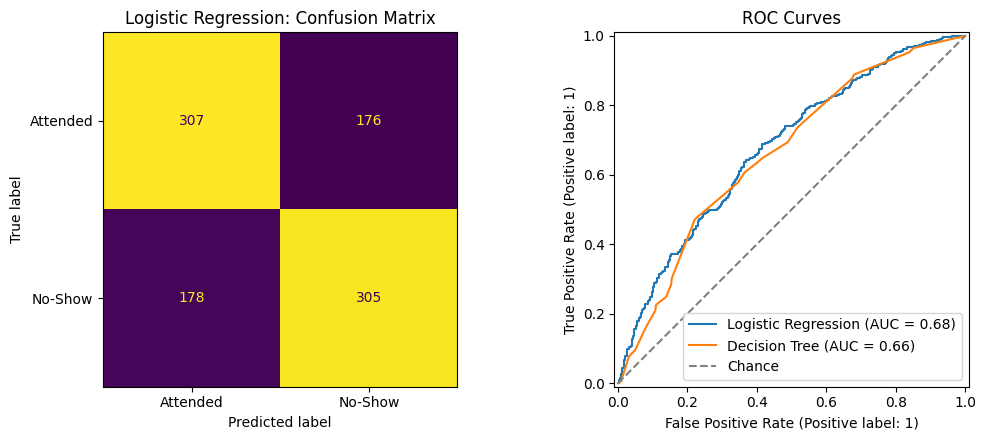

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, logreg_pred), display_labels=['Attended', 'No-Show']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression: Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, logreg_proba, ax=axes[1], name='Logistic Regression')
RocCurveDisplay.from_predictions(y_test, tree_proba, ax=axes[1], name='Decision Tree')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey', label='Chance')
axes[1].set_title('ROC Curves')
axes[1].legend()

plt.tight_layout()
plt.savefig('processed/fig4_eval.png', dpi=100)
plt.show()

In [17]:
print(classification_report(y_test, logreg_pred, target_names=['Attended', 'No-Show']))

              precision    recall  f1-score   support

    Attended       0.63      0.64      0.63       483
     No-Show       0.63      0.63      0.63       483

    accuracy                           0.63       966
   macro avg       0.63      0.63      0.63       966
weighted avg       0.63      0.63      0.63       966



## 8. Interpretation

Both baselines land close to a coin flip (~50–52% accuracy), as expected — the rule-based baseline has slightly better precision than the majority-class one, but its recall is very low: `previous_no_shows >= 2` only catches a small slice of actual no-shows, because many no-shows come from patients with 0 or 1 prior no-show (including first-time patients).

Logistic regression clearly beats both baselines and slightly edges out the decision tree on this first pass, while also being the more interpretable of the two — its coefficients are examined below.

In [18]:
cat_names = logreg_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_names)
coefs = logreg_pipe.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': coefs}).sort_values('coefficient', ascending=False)

print("Features associated with a HIGHER no-show risk:")
print(coef_df.head(6).to_string(index=False))
print("\nFeatures associated with a LOWER no-show risk:")
print(coef_df.tail(6).to_string(index=False))

Features associated with a HIGHER no-show risk:
                  feature  coefficient
        previous_no_shows     0.622284
appointment_day_Wednesday     0.303136
 appointment_day_Thursday     0.269532
   appointment_day_Monday     0.216372
    distance_missing_flag     0.145500
reminder_channel_WhatsApp     0.143831

Features associated with a LOWER no-show risk:
                              feature  coefficient
appointment_type_General Consultation    -0.184544
                reminder_channel_None    -0.201324
             gender_Prefer not to say    -0.250823
                 is_first_appointment    -0.412113
                    reminder_sent_Yes    -0.452853
                 no_show_rate_history    -0.666916


**Reading the coefficients:**

- `previous_no_shows` is the strongest single numeric driver of higher risk, confirming Week 4's headline finding — every additional prior no-show pushes predicted risk up.
- `no_show_rate_history` and `reminder_sent_Yes` sit among the strongest features pulling risk **down** — a clean history rate and having received a reminder are both protective, which lines up with intuition and with the operational lever HealthConnect already has available (sending reminders).
- `is_first_appointment` also points toward lower risk. Combined with `no_show_rate_history` defaulting to 0 for first-timers, this suggests the model isn't simply penalising missing history — first appointments genuinely look somewhat safer than the "0% history but has attended before" case, which contradicts the naive assumption that first-timers are automatically the highest-risk group.
- Several `appointment_day` categories carry a mild positive coefficient (Wednesday, Thursday, Monday), a weaker and less intuitive pattern that's worth treating cautiously rather than acting on directly — it could easily be noise in a synthetic dataset rather than a real scheduling effect.

None of these effects are large enough on their own to make confident individual predictions — this is exactly what's expected of a first baseline, not a finished model.

## 9. Modelling Limitations

- **Ceiling on current performance.** An accuracy of ~63% and ROC-AUC of ~0.68 is a real improvement over both baselines, but it's a modest one — the available features only explain part of what drives a no-show. There's no information here on the more personal reasons a patient might miss an appointment (illness, transport breakdown, forgetting, competing responsibilities), which likely limits how much further a model can improve without new data.
- **Synthetic data.** All patterns found (reminders helping, prior no-shows predicting future ones) are intuitive and plausible, but they come from a fictional, generated dataset. Any real deployment would need re-validation against real HealthConnect appointment data before being trusted operationally.
- **`waiting_time_minutes` was excluded, not just because of missingness, but on timing grounds** — this is a design decision that trades away a column with some raw statistical signal in favour of a model that will actually work at the point in time when HealthConnect needs a prediction (before, not after, the appointment).
- **Day-of-week effects are noisy.** The coefficients on individual weekdays are inconsistent enough that they shouldn't be treated as a reliable operational signal yet.
- **No hyperparameter tuning or cross-validation was performed.** A single 80/20 split, as intended for a first baseline — a more robust estimate of performance (e.g. cross-validation) is planned for Week 6.

## 10. Recommendations for Week 6

1. Move beyond a single train/test split to cross-validation (grouped by patient) for a more reliable performance estimate.
2. Try a tuned tree-based ensemble (e.g. Random Forest or Gradient Boosting) now that a credible linear baseline exists to measure it against.
3. Investigate the day-of-week effect further before deciding whether to keep it, since it looks more like noise than signal at this stage.
4. Revisit feature importance after tuning to confirm which engineered features actually earn their place versus which ones a regularised or tuned model would drop.
5. If the clinic's actual intervention (e.g. an extra reminder call) is cheap, consider optimising the classification threshold for recall rather than accuracy, since missing a genuine no-show is likely costlier to the clinic than a false alarm.

## 11. Cross-Track Collaboration

**Track interacted with:** Data Analytics.

**Information/output exchanged:** The Data Analytics track's Week 5 KPI work (e.g. overall no-show rate, no-show rate by reminder status, no-show rate by prior history) covers some of the same ground as the exploratory analysis above, from a business-reporting angle rather than a modelling one.

**Why relevant:** Aligning on the same underlying numbers (e.g. the ~51% no-show rate once cancellations are excluded, the reminder effect) avoids the two tracks presenting slightly different figures to HealthConnect stakeholders, and the Data Analytics framing of *why* a KPI matters to the business helped sanity-check which engineered features here are worth featuring in the Week 5 summary versus which are more of an internal modelling detail.

**What changed as a result:** The reminder-related features (`reminder_sent`, `reminder_channel`) were kept in the feature set at their original categorical granularity, rather than being collapsed into a single "reminder sent yes/no" flag, since the Analytics track's breakdown suggested the specific channel might carry a distinct pattern worth preserving for later analysis.

## 12. Assumptions, Limitations, Risks & Dependencies — Week 5 Update

| Item | Status |
|---|---|
| Dataset is synthetic but representative enough to build/test an approach | **Still relevant** — unchanged, carried from Week 4 |
| `previous_no_shows`/`previous_appointments` count only prior appointments | **Still relevant** — assumed true, not verifiable from the data alone |
| `waiting_time_minutes` is a leakage/timing risk | **Resolved this week** — excluded from the feature set based on when it would be known in practice |
| `reminder_channel` missingness pattern | **Resolved** — confirmed structural (no reminder sent), filled with an explicit "None" category |
| `distance_to_clinic_km` missingness | **Resolved (with residual risk)** — imputed with the median plus a missingness flag; the *reason* for the gap in these 90 rows is still unknown |
| No information on reasons for no-shows | **Still relevant** — unchanged, limits how targeted any intervention can be |
| Ethical use of predictions | **Still relevant** — predictions should inform extra support for flagged patients, not reduced access to care |
| New: single train/test split may not give a stable performance estimate | **New this week** — flagged for Week 6 (move to cross-validation) |
| New: day-of-week effects may be noise | **New this week** — flagged for further investigation before being used operationally |

## 13. Week 5 Summary

**Planned for Week 5:** Clean and impute the flagged columns, engineer age- and history-based features, build the baseline and a first logistic regression model, and get an initial read on performance.

**Actually completed:** All of the above, plus a decision tree trained for comparison, a patient-grouped train/test split to avoid leakage from repeat patients, and a resolved (not just flagged) decision on `waiting_time_minutes`.

**Key outcome:** Logistic regression reaches ~63% accuracy and a ROC-AUC of ~0.68, clearly ahead of both the majority-class baseline (50%) and the simple prior-no-shows rule (~52% accuracy, very low recall) — a modest but real first improvement, consistent with what a first baseline on this kind of data should be expected to achieve.

**Major challenge:** Deciding what to do with `waiting_time_minutes` required stepping back from the raw statistics (it isn't perfectly correlated with the outcome) and reasoning about *when*, operationally, the model would actually need to make its prediction.

**Change to the Week 4 approach:** None in direction — the plan (baseline → logistic regression → tree-based comparison, grouped split) was followed as proposed. The one refinement was resolving the `waiting_time_minutes` question definitively rather than leaving it open.

**Remaining work / Week 6 focus:** Cross-validation, a tuned ensemble model, further investigation of the day-of-week effect, and a look at threshold optimisation for the clinic's actual intervention cost.